# Importing Libraries

In [1]:
import os
import cv2
import glob
import yaml
import random
import pathlib
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm.notebook import trange, tqdm
from IPython.display import Image, Video
from IPython.display import Image, display
from sklearn.metrics import precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')
import optuna
import pprint

<a id="pre"></a>

<h1 style="
    background-color: #A3C4F3;
    background-size: cover;
    background-position: center;
    font-family: 'Times New Roman', serif;
    font-size: 1.5em;
    color: black;
    text-align: center;
    padding: 15px;
    border-radius: 15px 50px;
    border: 1px solid black;
">
    Discription File For The Custom Dataset
</h1>

In [2]:
train_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/train/images'
val_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/val/images'
test_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/test/images'

yaml_content = f"""
test: {test_path}
train: {train_path}
val: {val_path}

nc: 2
names: ['car', 'truck', 'bus']
"""
output_path = 'data.yaml'
with open(output_path, 'w') as file:
    file.write(yaml_content)
color_code = "\033[38;2;163;196;243m"
reset_code = "\033[0m"
print(f"{color_code}YAML file has been saved to {output_path}{reset_code}")

YAML file has been saved to data.yaml


In [4]:
output_path = 'data.yaml'
with open(output_path, 'r') as file:
    data = yaml.safe_load(file)
class_names = data['names']
print(f"{color_code}Class Names:{reset_code} {class_names}")

Class Names: ['car', 'truck', 'bus']


In [5]:
import os
import random
from PIL import Image

images_folder = train_path
image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_image = random.choice(image_files)
random_image_path = os.path.join(images_folder, random_image)
image = Image.open(random_image_path)
image_size = image.size
image_mode = image.mode
num_channels = image.layers if hasattr(image, 'layers') else len(image.getbands())
print(f"Random Image: {random_image}")
print(f"Image Size: {image_size}")
print(f"Image Mode (Channels): {image_mode}")
print(f"Number of Channels: {num_channels}")

Random Image: Screenshot-151-_png.rf.74ab95ac6ae81a9fcb27253187756762.jpg
Image Size: (1920, 1080)
Image Mode (Channels): RGB
Number of Channels: 3


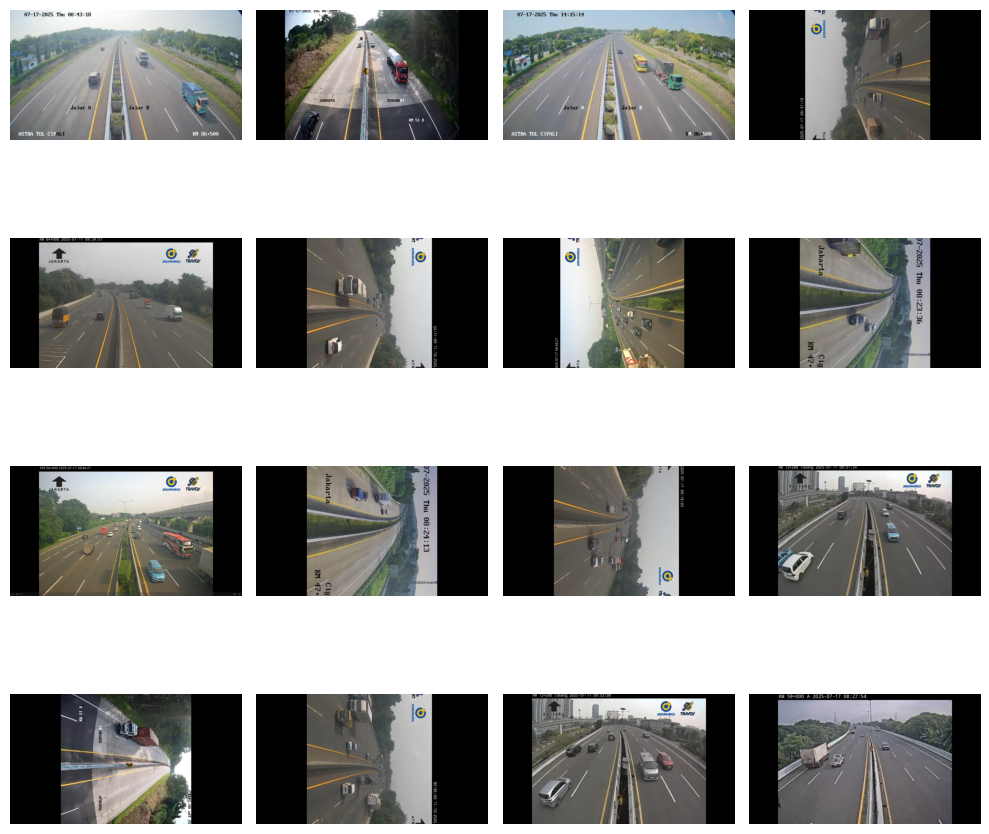

In [6]:
image_files = [f for f in os.listdir(train_path) if f.endswith('.jpg')]
selected_images = random.sample(image_files, 16)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img_path = os.path.join(train_path, selected_images[i])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Training

In [7]:
def objective(trial):
    lr0 = trial.suggest_float('lr0', 1e-3, 1e-1, log=True)
    momentum = trial.suggest_float('momentum', 0.8, 0.98)
    dropout = trial.suggest_float('dropout', 0.0, 0.2)

    try:
        model = YOLO('yolo11l.yaml')
        results = model.train(
            data="/home/athena-3/Documents/Finetune_Vehicle/yolov11m/dataset/dataset/data.yaml",
            epochs=50,
            imgsz=416,
            lr0=lr0,
            momentum=momentum,
            dropout=dropout,
            project='yolo_optuna_tune',
            name=f'trial_{trial.number}',
            device=0,
            verbose=False
        )

        return results.box.map
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return optuna.TrialPruned()

In [8]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-07-22 21:33:04,698] A new study created in memory with name: no-name-352dd22f-5676-4cbf-a1c3-3449b7b81070


New https://pypi.org/project/ultralytics/8.3.169 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.168 🚀 Python-3.13.5 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/athena-3/Documents/Finetune_Vehicle/yolov11m/dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.11588377553767451, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.006982162349217045, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.yaml, momentum=0

100%|██████████████████████████████████████| 5.35M/5.35M [00:01<00:00, 3.48MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 244.7±20.4 MB/s, size: 106.5 KB)


train: Scanning /home/athena-3/Documents/Finetune_Vehicle/yolov11m/dataset/datas


...


50 epochs completed in 0.143 hours.
Optimizer stripped from yolo_optuna_tune/trial_49/weights/last.pt, 51.2MB
Optimizer stripped from yolo_optuna_tune/trial_49/weights/best.pt, 51.2MB

Validating yolo_optuna_tune/trial_49/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.13.5 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
YOLO11l summary (fused): 190 layers, 25,281,625 parameters, 0 gradients, 86.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         60        262      0.904      0.835       0.94      0.675
Speed: 0.0ms preprocess, 2.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to yolo_optuna_tune/trial_49


[I 2025-07-23 04:48:03,538] Trial 49 finished with value: 0.6754829409492206 and parameters: {'lr0': 0.02802403624781113, 'momentum': 0.8458989530608939, 'dropout': 0.07023329761540545}. Best is trial 0 with value: 0.6754829409492206.


Best trial:
  Value: 0.6754829409492206
  Params: 
    lr0: 0.006982162349217045
    momentum: 0.9698522630378373
    dropout: 0.11588377553767451


In [9]:
best_params = study.best_trial.params
final_model = YOLO('yolo11l.yaml')

final_results = final_model.train(
    data="/home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/data.yaml",
    epochs=100,
    imgsz=416,
    device=0,
    project='yolo_final_train',
    name='best_run',
    **best_params
)

New https://pypi.org/project/ultralytics/8.3.169 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.168 🚀 Python-3.13.5 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.11588377553767451, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.006982162349217045, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.yaml, momentum=

train: Scanning /home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/datas

train: New cache created: /home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/train/labels.cache


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 79.4±55.7 MB/s, size: 117.5 KB)


val: Scanning /home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset

...

    100/100      5.55G     0.7212     0.3883     0.8507         54        416: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all         60        262      0.902      0.858      0.939      0.694



100 epochs completed in 0.281 hours.
Optimizer stripped from yolo_final_train/best_run/weights/last.pt, 51.2MB
Optimizer stripped from yolo_final_train/best_run/weights/best.pt, 51.2MB

Validating yolo_final_train/best_run/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.13.5 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
YOLO11l summary (fused): 190 layers, 25,281,625 parameters, 0 gradients, 86.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         60        262      0.884      0.866      0.941        0.7
                   bus         17         17      0.927      0.882       0.96      0.745
                   car         50        179       0.89      0.877      0.938      0.648
                 truck         42         66      0.834      0.839      0.925      0.706
Speed: 0.0ms preprocess, 2.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to yolo_final_train/best_run


<a id="pre"></a>

<h1 style="
    background-color: #A3C4F3;
    background-size: cover;
    background-position: center;
    font-family: 'Times New Roman', serif;
    font-size: 1.5em;
    color: black;
    text-align: center;
    padding: 15px;
    border-radius: 15px 50px;
    border: 1px solid black;
">
    Training Results
</h1>

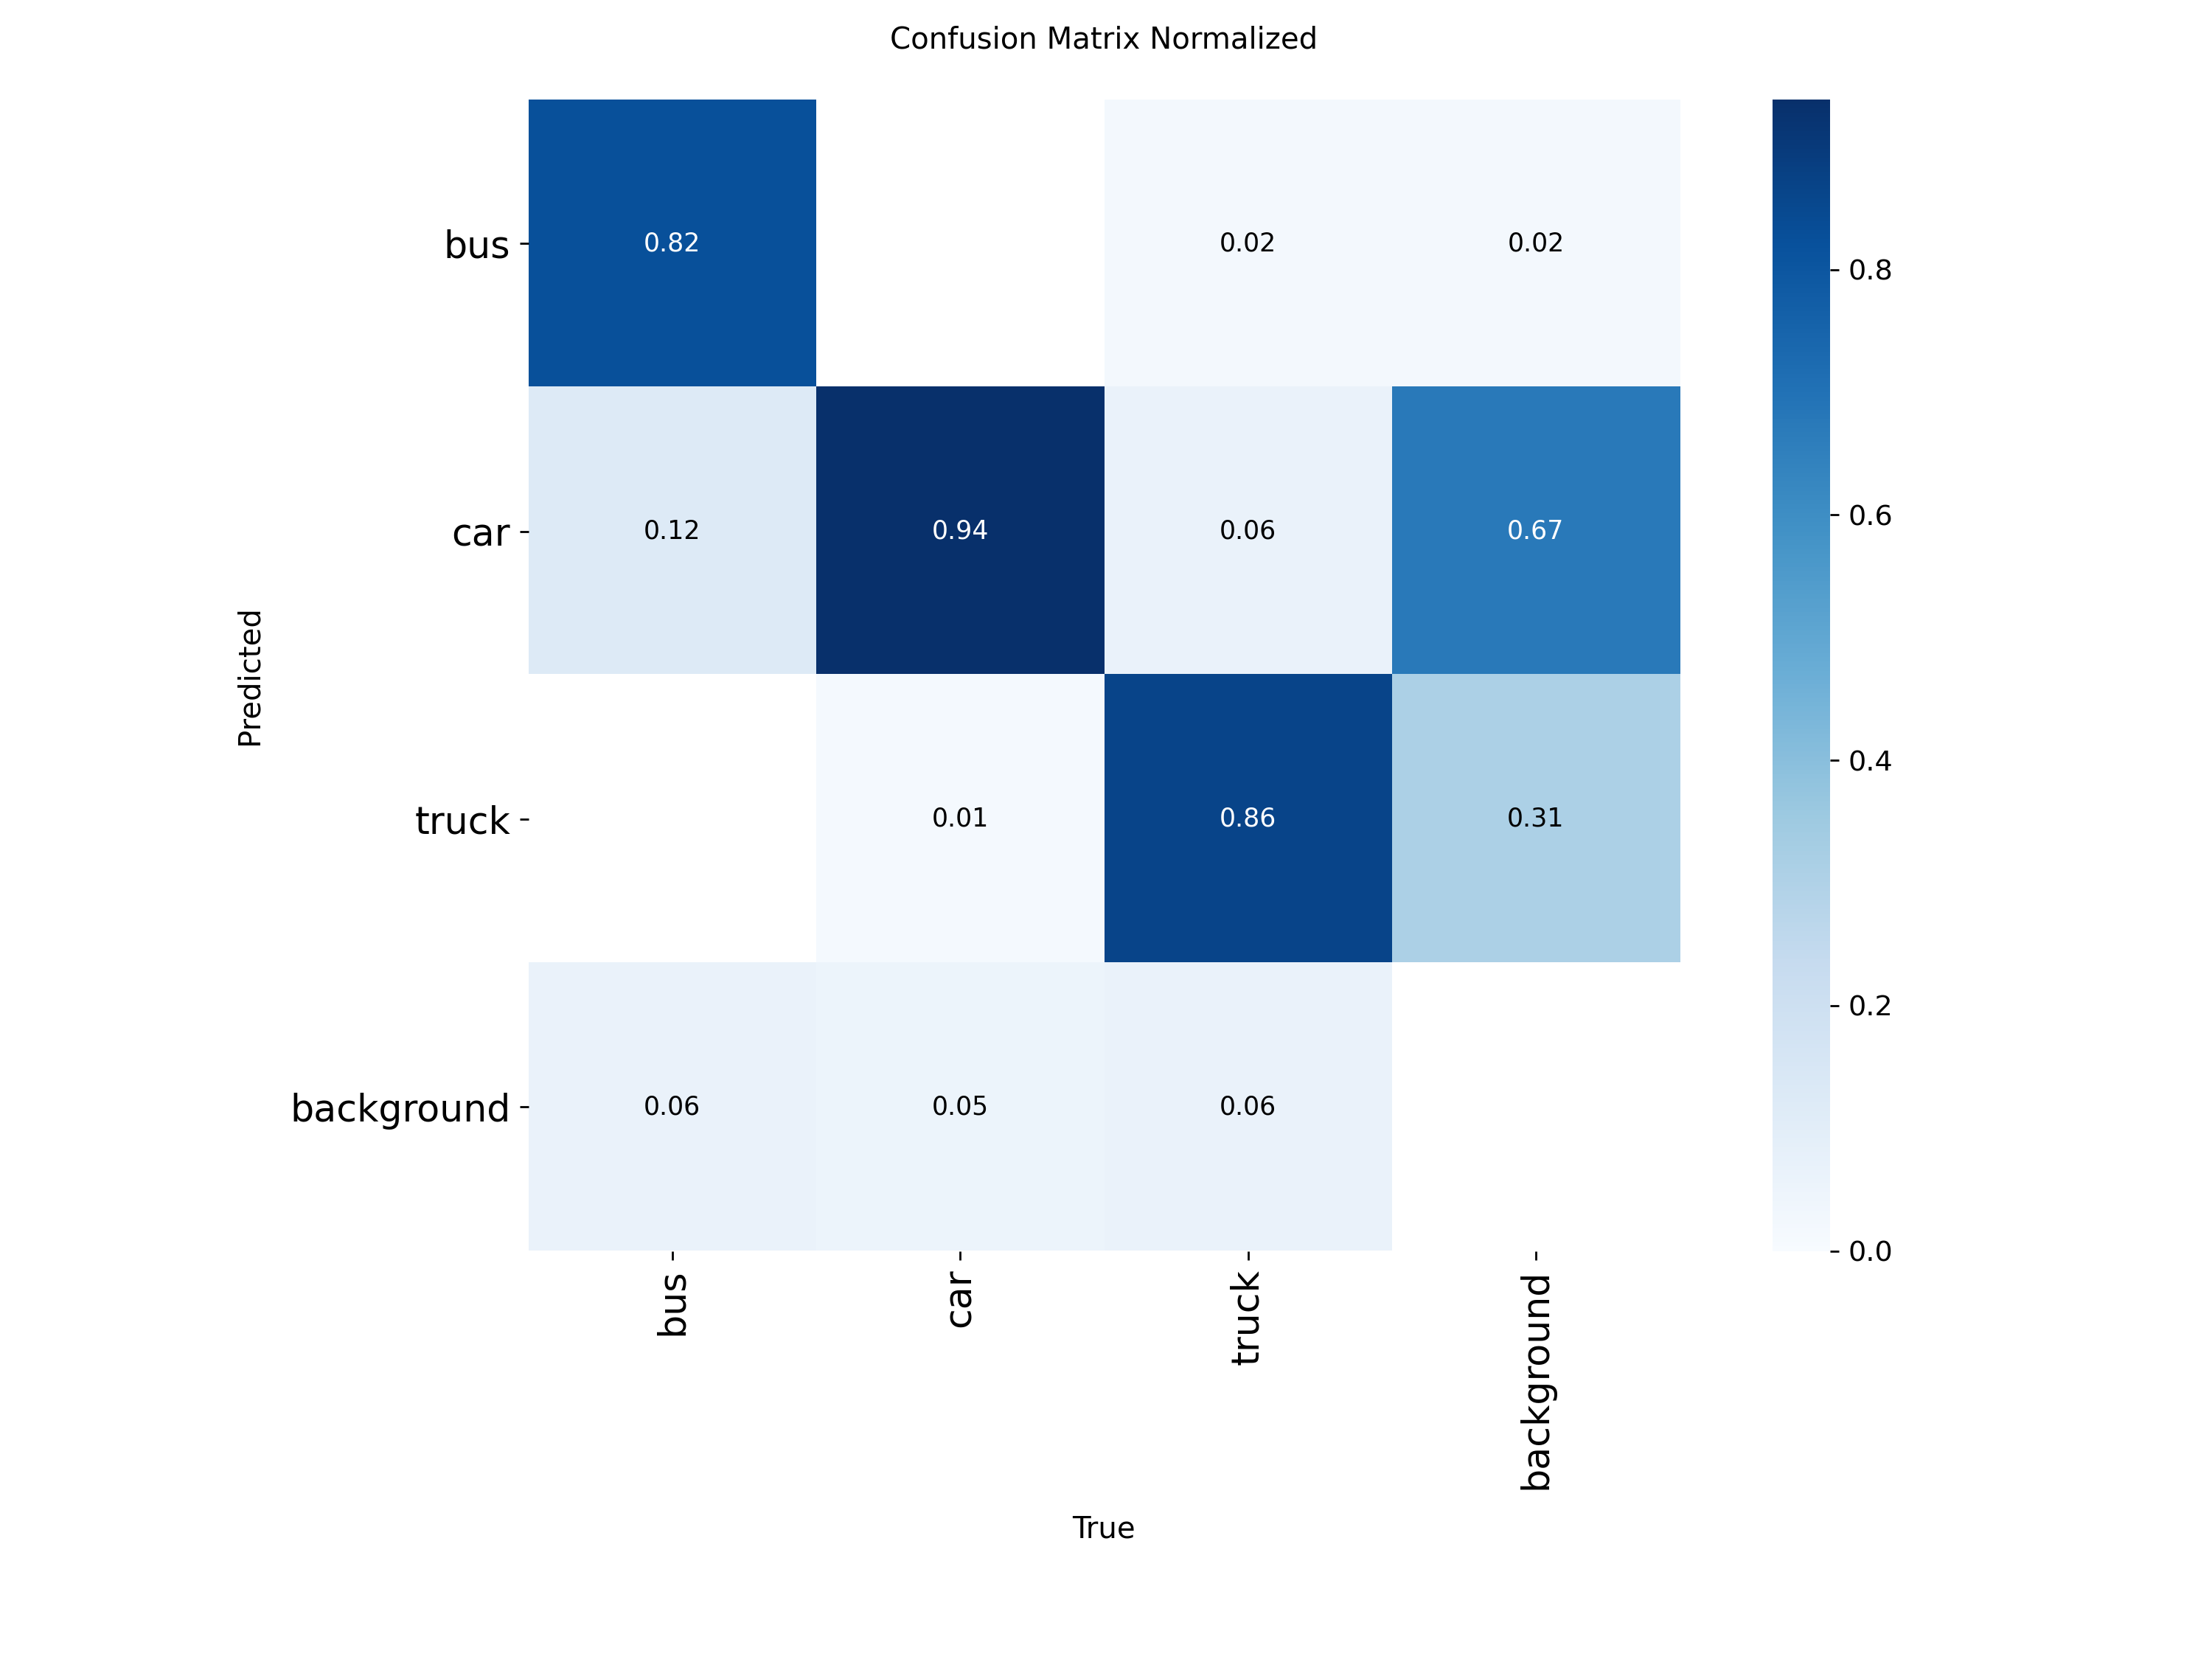

In [10]:
from IPython.display import Image, display
image_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/yolo_final_train/best_run/confusion_matrix_normalized.png'
display(Image(filename=image_path))

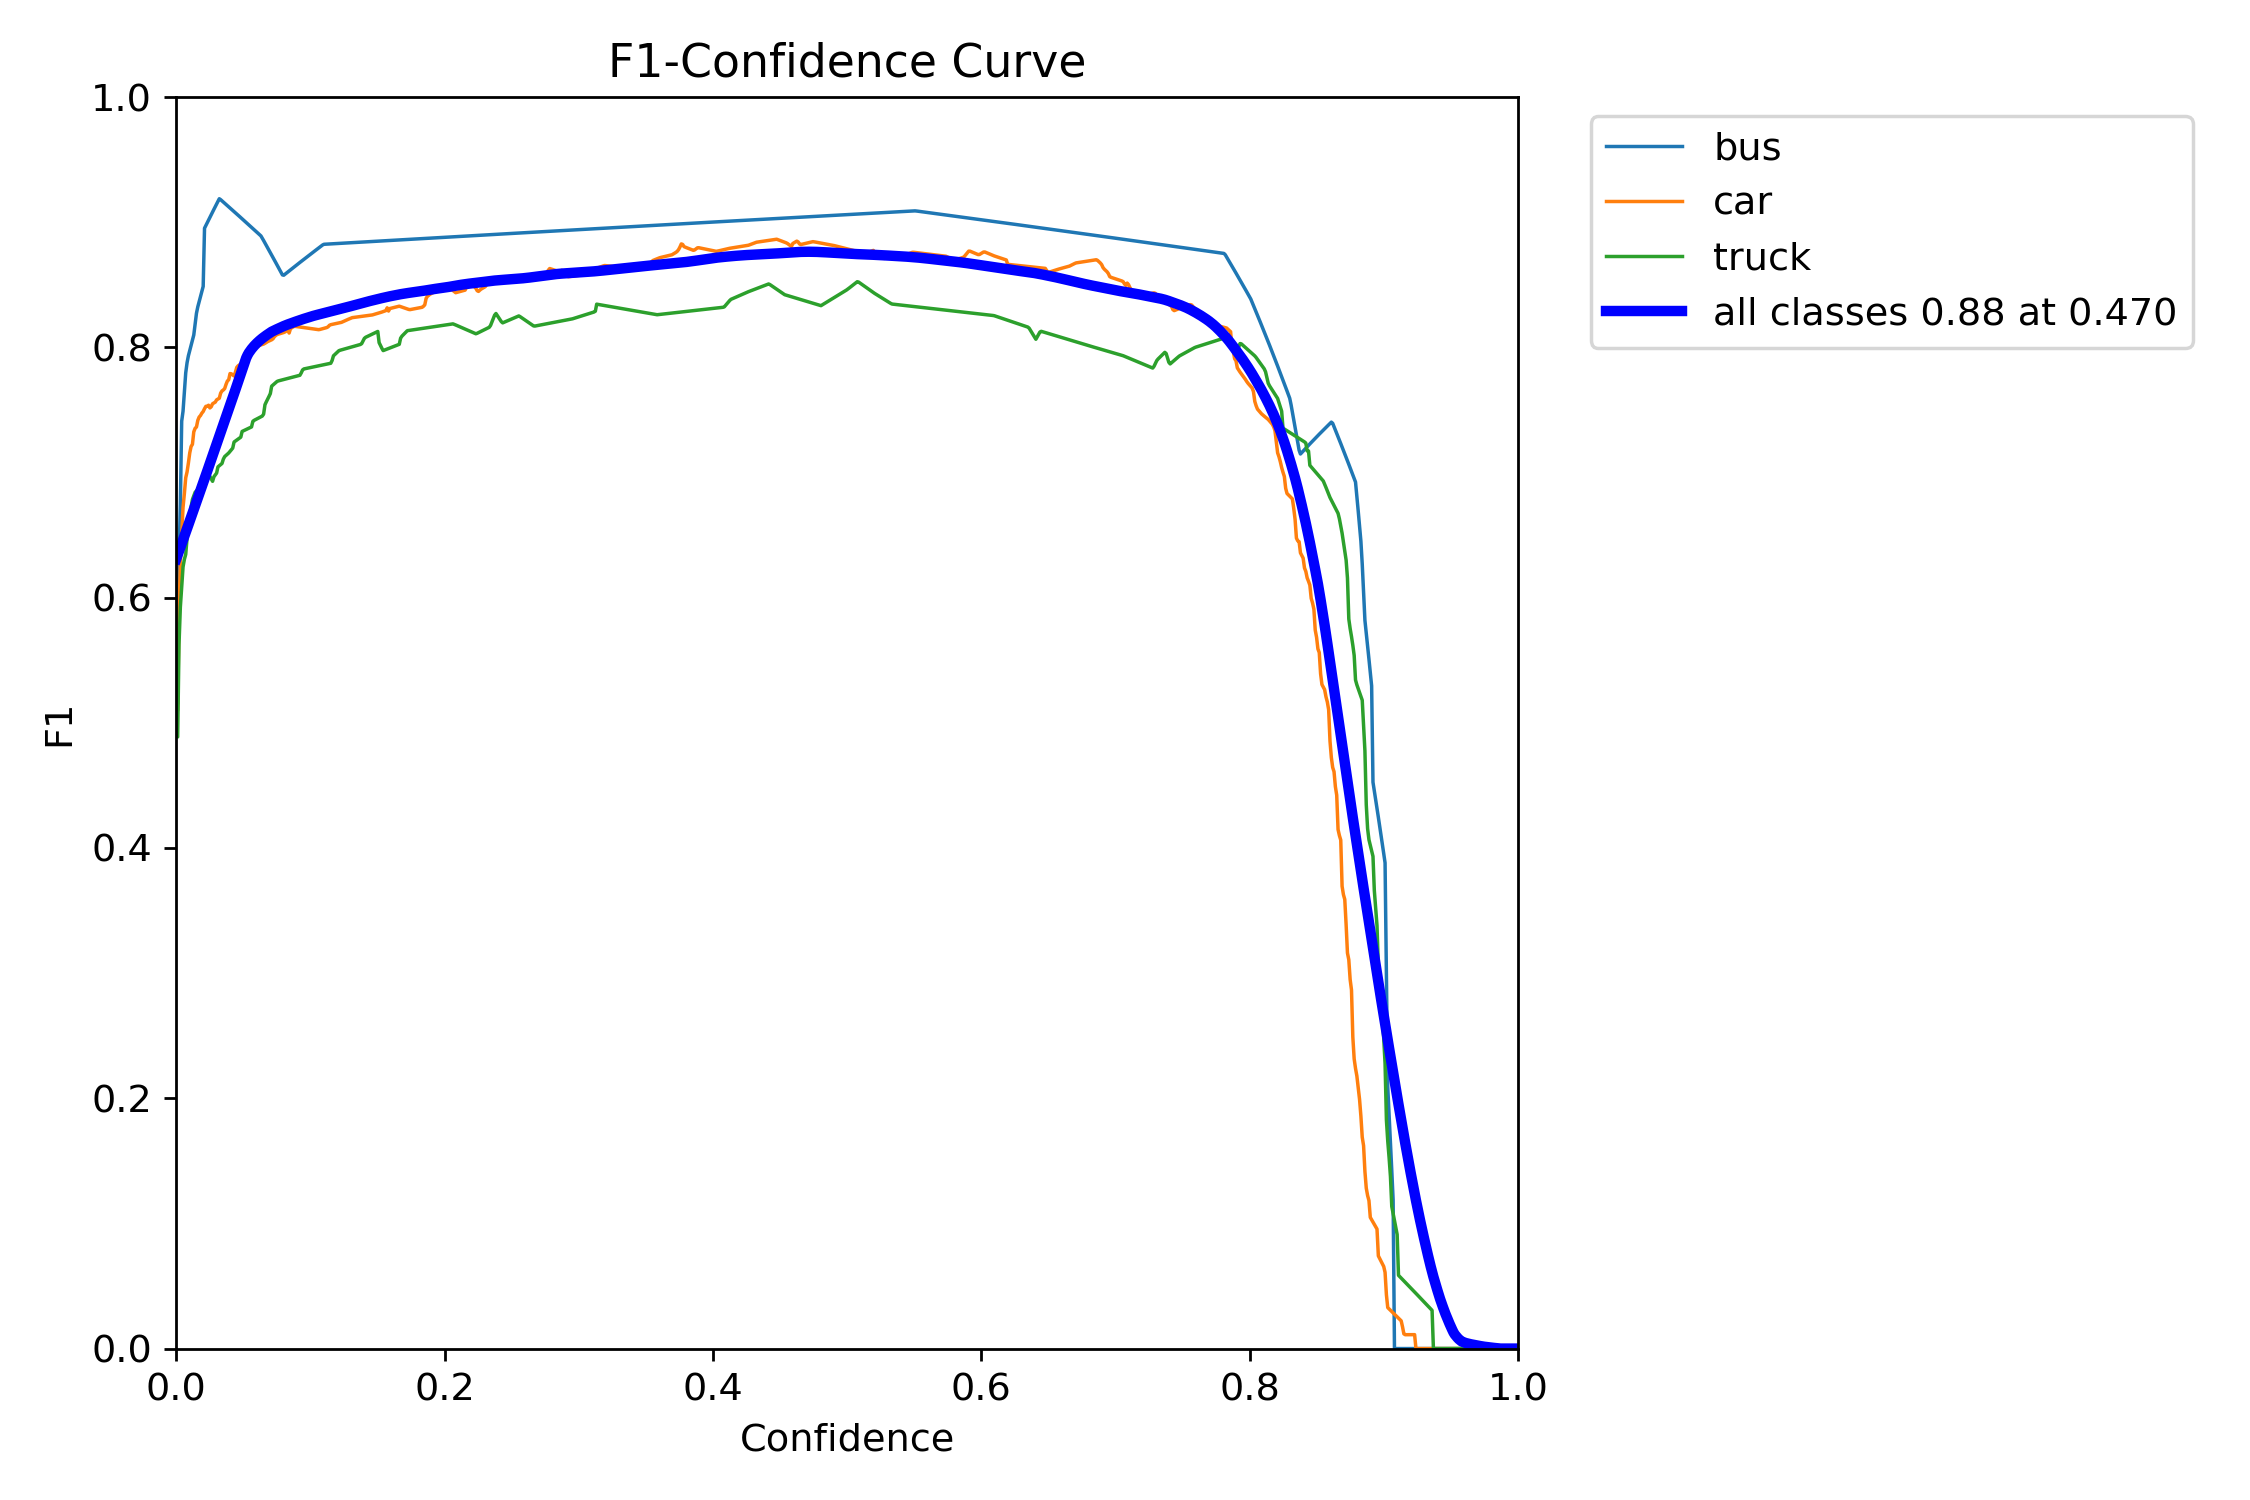

In [11]:
image_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/yolo_final_train/best_run/BoxF1_curve.png'
display(Image(filename=image_path))

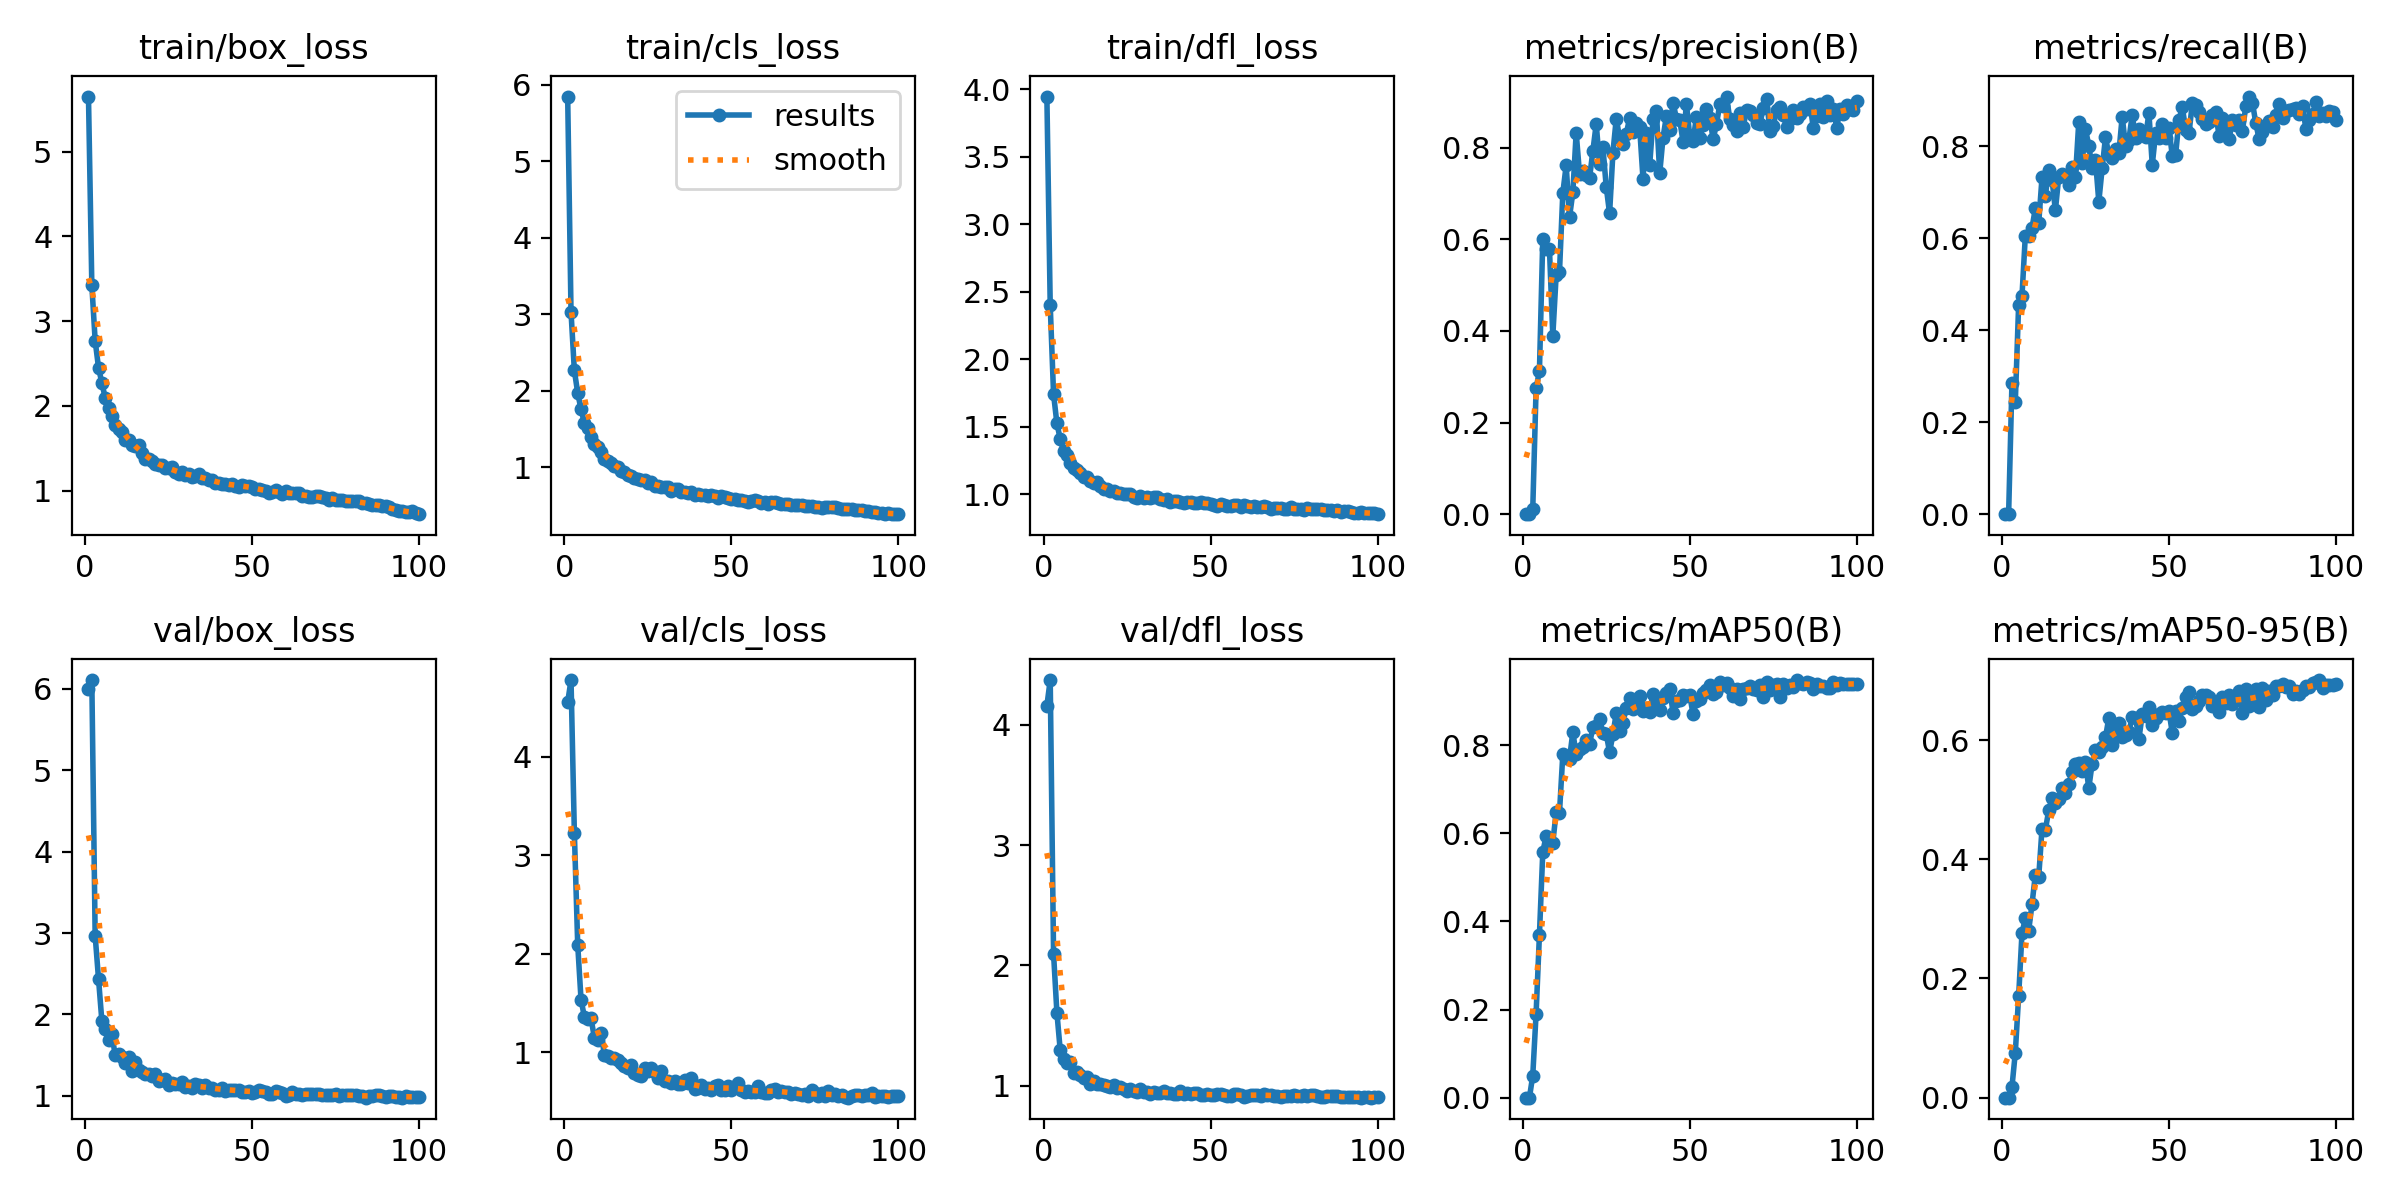

In [12]:
image_path = '/home/athena-3/Documents/Finetune_Vehicle/yolov11l/yolo_final_train/best_run/results.png'
display(Image(filename=image_path))

# Inference

In [13]:
best_model = YOLO('/home/athena-3/Documents/Finetune_Vehicle/yolov11l/yolo_final_train/best_run/weights/best.pt')
metrics = best_model.val(split = 'test')

Ultralytics 8.3.168 🚀 Python-3.13.5 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
YOLO11l summary (fused): 190 layers, 25,281,625 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 229.4±88.8 MB/s, size: 120.2 KB)


val: Scanning /home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset

val: New cache created: /home/athena-3/Documents/Finetune_Vehicle/yolov11l/dataset/dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         30        140      0.939      0.839      0.941      0.704
                   bus          6          6      0.934      0.833      0.904      0.753
                   car         28        104      0.967       0.85      0.973      0.673
                 truck         18         30      0.917      0.833      0.945      0.685
Speed: 0.7ms preprocess, 8.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val


In [18]:
best_model = YOLO('/home/athena-3/Documents/Finetune_Vehicle/yolov11l/yolo_final_train/best_run2/weights/best.pt')
hyperparameters = best_model.args
pprint.pprint(hyperparameters)

{'data': '/home/athena-3/Documents/Finetune_Vehicle/yolov11m/dataset/dataset/data.yaml',
 'imgsz': 416,
 'model': '/home/athena-3/Documents/Finetune_Vehicle/yolov11m/yolo_final_train/best_run2/weights/best.pt',
 'single_cls': False,
 'task': 'detect'}
